# CNN 

### 1. Instalar las librerías

In [1]:
%pip install tensorflow pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


### 2. Importar las librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


### 3. Cargar dataset y analisis

In [3]:
# Cargar la data
df = pd.read_csv("data_Apalachicola Bay, FL.csv")

# Ver primeras filas
df.head()

,fecha_hora_EST,fecha_hora_UTC,temperatura_agua_C,pH,conductividad_especifica_mS_cm,presion_atmosferica_hPa,hora_del_dia,radiacion_PAR_mmol_m2_15min,turbidez_FNU_NTU,oxigeno_disuelto_mg_L
0,2022-08-01T00:00,2022-08-01T05:00+00:00,32.7,7.2,6.66,1022,0.00,0.0,9,5.2
1,2022-08-01T00:15,2022-08-01T05:15+00:00,32.7,7.2,6.66,1022,0.25,0.0,7,4.6
2,2022-08-01T00:30,2022-08-01T05:30+00:00,32.7,7.1,6.65,1022,0.50,0.0,7,3.9
3,2022-08-01T00:45,2022-08-01T05:45+00:00,32.7,7.0,6.64,1022,0.75,0.0,8,3.3
4,2022-08-01T01:00,2022-08-01T06:00+00:00,32.7,7.0,6.63,1022,1.00,0.0,7,2.7


In [14]:
df.columns

Index(['fecha_hora_EST', 'fecha_hora_UTC', 'temperatura_agua_C', 'pH',
       'conductividad_especifica_mS_cm', 'presion_atmosferica_hPa',
       'hora_del_dia', 'radiacion_PAR_mmol_m2_15min', 'turbidez_FNU_NTU',
       'oxigeno_disuelto_mg_L', 'fecha'],
      dtype='object')

In [18]:
print("Registros:", df.shape[0])
print("Columnas:", df.shape[1])

Registros: 31163
Columnas: 11


In [22]:
# Asegurar que sea tipo fecha
df['fecha_hora_EST'] = pd.to_datetime(df['fecha_hora_EST'])

primera_fecha = df['fecha_hora_EST'].min()
ultima_fecha = df['fecha_hora_EST'].max()

print("Primera fecha:", primera_fecha)
print("Última fecha:", ultima_fecha)

Primera fecha: 2022-08-01 00:00:00
Última fecha: 2023-12-30 18:15:00


### 4. Selección de variables, limpieza y validación de datos
Este bloque define las entradas y el objetivo, convierte fechas y valores numéricos, verifica datos inválidos, elimina registros duplicados y ordena las mediciones cronológicamente.

In [4]:
variables = [
    "temperatura_agua_C",
    "pH",
    "conductividad_especifica_mS_cm",
    "presion_atmosferica_hPa",
    "hora_del_dia",
    "radiacion_PAR_mmol_m2_15min",
    "turbidez_FNU_NTU"
]

objetivo = "oxigeno_disuelto_mg_L"

df["fecha"] = pd.to_datetime(
    df["fecha_hora_UTC"],
    utc=True,
    errors="coerce"
)

for columna in variables + [objetivo]:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df[variables + [objetivo]] = df[variables + [objetivo]].replace(
    [np.inf, -np.inf], np.nan
)

display(df[variables + [objetivo]].isna().sum())

assert df[variables + [objetivo, "fecha"]].notna().all().all(), \
    "Hay datos ausentes o inválidos. Revísalos antes de continuar."

df = (
    df.drop_duplicates()
      .sort_values("fecha")
      .reset_index(drop=True)
)

assert not df["fecha"].duplicated().any(), \
    "Hay fechas duplicadas. Revísalas antes de continuar."

print("Registros:", len(df))
display(df.head())

temperatura_agua_C                0
pH                                0
conductividad_especifica_mS_cm    0
presion_atmosferica_hPa           0
hora_del_dia                      0
radiacion_PAR_mmol_m2_15min       0
turbidez_FNU_NTU                  0
oxigeno_disuelto_mg_L             0
dtype: int64

Registros: 31163


,fecha_hora_EST,fecha_hora_UTC,temperatura_agua_C,pH,conductividad_especifica_mS_cm,presion_atmosferica_hPa,hora_del_dia,radiacion_PAR_mmol_m2_15min,turbidez_FNU_NTU,oxigeno_disuelto_mg_L,fecha
0,2022-08-01T00:00,2022-08-01T05:00+00:00,32.7,7.2,6.66,1022,0.00,0.0,9,5.2,2022-08-01 05:00:00+00:00
1,2022-08-01T00:15,2022-08-01T05:15+00:00,32.7,7.2,6.66,1022,0.25,0.0,7,4.6,2022-08-01 05:15:00+00:00
2,2022-08-01T00:30,2022-08-01T05:30+00:00,32.7,7.1,6.65,1022,0.50,0.0,7,3.9,2022-08-01 05:30:00+00:00
3,2022-08-01T00:45,2022-08-01T05:45+00:00,32.7,7.0,6.64,1022,0.75,0.0,8,3.3,2022-08-01 05:45:00+00:00
4,2022-08-01T01:00,2022-08-01T06:00+00:00,32.7,7.0,6.63,1022,1.00,0.0,7,2.7,2022-08-01 06:00:00+00:00


### Separar los periodos y escalar
Mantenemos la separación temporal anterior: 60 % entrenamiento, 20 % validación y 20 % prueba, con un margen de 24 horas. (para dejar una separación temporal entre entrenamiento, validación y prueba).

Como las mediciones están separadas por 15 minutos, y las más cercanas pueden parecerse mucho. Este margen reduce la dependencia entre los últimos ejemplos de entrenamiento y los primeros de validación, haciendo la evaluación más exigente.

In [5]:
n = len(df)

inicio_val = df["fecha"].iloc[int(n * 0.60)]
inicio_test = df["fecha"].iloc[int(n * 0.80)]

margen = pd.Timedelta(hours=24)

train = df[
    df["fecha"] < inicio_val - margen
].copy()

val = df[
    (df["fecha"] >= inicio_val) &
    (df["fecha"] < inicio_test - margen)
].copy()

test = df[
    df["fecha"] >= inicio_test
].copy()

print("Entrenamiento:", len(train))
print("Validación:", len(val))
print("Prueba reservada:", len(test))

Entrenamiento: 18601
Validación: 6179
Prueba reservada: 6233


### Escalar las variables
Esto evita que variables con valores grandes, como la presión, tengan una escala muy diferente del pH.
El escalador aprende únicamente del entrenamiento.

In [6]:
escalador = StandardScaler()

escalador.fit(train[variables])

,copy,True
,with_mean,True
,with_std,True


### 6. Crear las secuencias para la CNN
Cada ejemplo tendrá forma 8 × 7: ocho instantes y siete variables.
Como el CSV tiene huecos temporales, solo aceptaremos secuencias con intervalos exactos de 15 minutos.

In [7]:
VENTANA = 8

def crear_secuencias(datos):
    X_escalado = escalador.transform(
        datos[variables]
    ).astype("float32")

    valores_y = datos[objetivo].to_numpy(dtype="float32")
    fechas = datos["fecha"].reset_index(drop=True)

    secuencias = []
    objetivos = []
    fechas_salida = []

    for fin in range(VENTANA - 1, len(datos)):
        inicio = fin - VENTANA + 1

        intervalos = (
            fechas.iloc[inicio:fin + 1]
            .diff()
            .iloc[1:]
        )

        if intervalos.eq(pd.Timedelta(minutes=15)).all():
            secuencias.append(X_escalado[inicio:fin + 1])
            objetivos.append(valores_y[fin])
            fechas_salida.append(fechas.iloc[fin])

    if not secuencias:
        raise ValueError("No hay suficientes secuencias continuas.")

    return (
        np.asarray(secuencias, dtype="float32"),
        np.asarray(objetivos, dtype="float32"),
        pd.DatetimeIndex(fechas_salida)
    )

X_train, y_train, fechas_train = crear_secuencias(train)
X_val, y_val, fechas_val = crear_secuencias(val)

print("Forma del entrenamiento:", X_train.shape)
print("Forma de la validación:", X_val.shape)

Forma del entrenamiento: (18049, 8, 7)
Forma de la validación: (5787, 8, 7)


Se construyeron 18.049 secuencias de entrenamiento y 5.787 de validación. Cada secuencia contiene ocho mediciones consecutivas de siete variables ambientales.

### 7. Construir la CNN
Empezamos con una arquitectura pequeña. La salida tiene una sola neurona porque queremos estimar un valor de oxígeno.

In [8]:
keras.utils.set_random_seed(42)

modelo_cnn = keras.Sequential([
    keras.Input(shape=(VENTANA, len(variables))),

    layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",
        activation="relu"
    ),

    layers.Conv1D(
        filters=16,
        kernel_size=3,
        padding="causal",
        activation="relu"
    ),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),

    layers.Dropout(0.1),

    # Salida positiva para el oxígeno disuelto
    layers.Dense(1, activation="softplus")
])

modelo_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss="mse",
    metrics=["mae"]
)

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,417 (25.07 KB)

 Trainable params: 6,417 (25.07 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Entrenar y detener cuando deje de mejorar
Una época es una pasada por los datos de entrenamiento. Pondremos un máximo de 150, pero se detendrá si el MAE de validación no mejora durante 15 épocas.

In [9]:
parada_temprana = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=15,
    restore_best_weights=True
)

historial = modelo_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    shuffle=False,
    callbacks=[parada_temprana],
    verbose=2
)

Epoch 1/150
283/283 - 9s - 33ms/step - loss: 7.8407 - mae: 2.1694 - val_loss: 10.9247 - val_mae: 2.5769
Epoch 2/150
283/283 - 4s - 14ms/step - loss: 5.2903 - mae: 1.8384 - val_loss: 4.5600 - val_mae: 1.6566
Epoch 3/150
283/283 - 6s - 21ms/step - loss: 3.4912 - mae: 1.5025 - val_loss: 2.5664 - val_mae: 1.2502
Epoch 4/150
283/283 - 4s - 15ms/step - loss: 2.4345 - mae: 1.2382 - val_loss: 2.0400 - val_mae: 1.1051
Epoch 5/150
283/283 - 5s - 19ms/step - loss: 2.0235 - mae: 1.1202 - val_loss: 1.9551 - val_mae: 1.0695
Epoch 6/150
283/283 - 4s - 13ms/step - loss: 1.8552 - mae: 1.0700 - val_loss: 1.9772 - val_mae: 1.0531
Epoch 7/150
283/283 - 4s - 13ms/step - loss: 1.7096 - mae: 1.0251 - val_loss: 2.0086 - val_mae: 1.0545
Epoch 8/150
283/283 - 5s - 16ms/step - loss: 1.6769 - mae: 1.0126 - val_loss: 2.3320 - val_mae: 1.1169
Epoch 9/150
283/283 - 4s - 13ms/step - loss: 1.6285 - mae: 0.9971 - val_loss: 2.2906 - val_mae: 1.1130
Epoch 10/150
283/283 - 6s - 20ms/step - loss: 1.5473 - mae: 0.9747 - val

### 9. Calcular los errores
Estos resultados corresponden a los mejores pesos recuperados

In [10]:
pred_train = modelo_cnn.predict(X_train, verbose=0).ravel()
pred_val = modelo_cnn.predict(X_val, verbose=0).ravel()

mae_train = mean_absolute_error(y_train, pred_train)
mae_val = mean_absolute_error(y_val, pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
r2_val = r2_score(y_val, pred_val)

mejor_epoca = np.argmin(historial.history["val_mae"]) + 1

print(f"Mejor época: {mejor_epoca}")
print(f"MAE entrenamiento: {mae_train:.4f} mg/L")
print(f"MAE validación:    {mae_val:.4f} mg/L")
print(f"RMSE validación:   {rmse_val:.4f} mg/L")
print(f"R² validación:     {r2_val:.4f}")

# Referencia: predecir siempre la media del entrenamiento
referencia = np.full(len(y_val), y_train.mean())

print(
    "MAE de referencia:",
    round(mean_absolute_error(y_val, referencia), 4),
    "mg/L"
)

Mejor época: 107
MAE entrenamiento: 0.7653 mg/L
MAE validación:    0.6916 mg/L
RMSE validación:   0.8668 mg/L
R² validación:     0.8766
MAE de referencia: 2.0454 mg/L


### 10. Grafica el aprendizaje

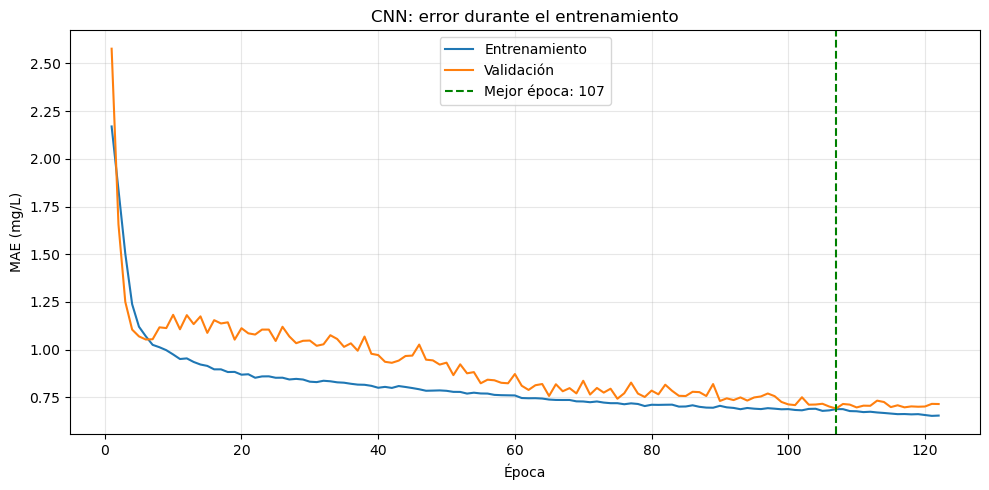

In [11]:
epocas = np.arange(1, len(historial.history["mae"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epocas,
    historial.history["mae"],
    label="Entrenamiento"
)

plt.plot(
    epocas,
    historial.history["val_mae"],
    label="Validación"
)

plt.axvline(
    mejor_epoca,
    color="green",
    linestyle="--",
    label=f"Mejor época: {mejor_epoca}"
)

plt.xlabel("Época")
plt.ylabel("MAE (mg/L)")
plt.title("CNN: error durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Mostrar los valores reales y predichos

In [24]:
comparacion_cnn = pd.DataFrame({
    "Fecha": fechas_val,
    "Oxigeno_real_mg_L": y_val,
    "Oxigeno_predicho_mg_L": pred_val
})

comparacion_cnn["Error_absoluto_mg_L"] = abs(
    comparacion_cnn["Oxigeno_real_mg_L"]
    - comparacion_cnn["Oxigeno_predicho_mg_L"]
)

display(comparacion_cnn.head(20).round(3))




,Fecha,Oxigeno_real_mg_L,Oxigeno_predicho_mg_L,Error_absoluto_mg_L
0,2023-02-27 21:00:00+00:00,7.9,8.636,0.736
1,2023-02-27 21:15:00+00:00,8.0,8.578,0.578
2,2023-02-27 21:30:00+00:00,8.1,8.629,0.529
3,2023-02-27 21:45:00+00:00,8.1,8.525,0.425
4,2023-02-27 22:00:00+00:00,8.1,8.440,0.340
5,2023-02-27 22:15:00+00:00,8.1,8.563,0.463
6,2023-02-27 22:30:00+00:00,8.1,8.552,0.452
7,2023-02-27 22:45:00+00:00,8.0,8.445,0.445
8,2023-02-27 23:00:00+00:00,8.0,8.595,0.595
9,2023-02-27 23:15:00+00:00,8.0,8.649,0.649


In [27]:
# Ordenamos para ver el mayor error absoluto
mayores_errores = comparacion_cnn.sort_values(
    by="Error_absoluto_mg_L",
    ascending=False
)

display(mayores_errores.head(20).round(3))

,Fecha,Oxigeno_real_mg_L,Oxigeno_predicho_mg_L,Error_absoluto_mg_L
752,2023-03-07 21:15:00+00:00,1.8,5.897,4.097
2861,2023-03-30 01:30:00+00:00,4.2,7.795,3.595
5475,2023-08-15 21:00:00+00:00,2.0,5.495,3.495
1460,2023-03-15 09:15:00+00:00,3.9,7.315,3.415
567,2023-03-05 23:00:00+00:00,5.7,9.106,3.406
2851,2023-03-29 23:00:00+00:00,4.4,7.789,3.389
1461,2023-03-15 09:30:00+00:00,3.6,6.741,3.141
2857,2023-03-30 00:30:00+00:00,4.9,7.867,2.967
2860,2023-03-30 01:15:00+00:00,4.9,7.842,2.942
3065,2023-04-01 06:45:00+00:00,0.3,3.236,2.936


### REPORTE DE CLASIFICACIÓN 


In [30]:

import numpy as np
from sklearn.metrics import classification_report

# Definir límites usando SOLO los datos de entrenamiento
limite_bajo, limite_alto = np.quantile(
    y_train,
    [0.33, 0.66]
)

print("Límite Bajo/Medio:", round(limite_bajo, 3), "mg/L")
print("Límite Medio/Alto:", round(limite_alto, 3), "mg/L")


# Función para convertir OD continuo en categorías
def clasificar_od(valores):

    return np.where(
        valores < limite_bajo,
        0,
        np.where(
            valores < limite_alto,
            1,
            2
        )
    )


# Convertir valores reales y predichos a clases
y_val_clases = clasificar_od(y_val)
pred_val_clases = clasificar_od(pred_val)

nombres_clases = [
    "OD bajo",
    "OD medio",
    "OD alto"
]


# Generar reporte de clasificación
print("\nREPORTE DE CLASIFICACIÓN\n")

print(
    classification_report(
        y_val_clases,
        pred_val_clases,
        target_names=nombres_clases,
        digits=3,
        zero_division=0
    )
)

Límite Bajo/Medio: 5.9 mg/L
Límite Medio/Alto: 8.3 mg/L

REPORTE DE CLASIFICACIÓN

              precision    recall  f1-score   support

     OD bajo      0.887     0.908     0.897      2286
    OD medio      0.643     0.704     0.672      2009
     OD alto      0.734     0.613     0.668      1492

    accuracy                          0.761      5787
   macro avg      0.755     0.742     0.746      5787
weighted avg      0.763     0.761     0.760      5787



El reporte de clasificación complementario obtuvo una exactitud global de 76.1 %. La categoría de OD bajo presentó el mejor desempeño, con un F1-score de 0.897, mientras que las categorías de OD medio y alto obtuvieron F1-scores de 0.672 y 0.668, respectivamente. El menor recall se observó en OD alto (0.613), indicando que el modelo presenta mayor dificultad para identificar todos los valores pertenecientes a esta categoría.

#### MATRIZ DE CONFUSIÓN


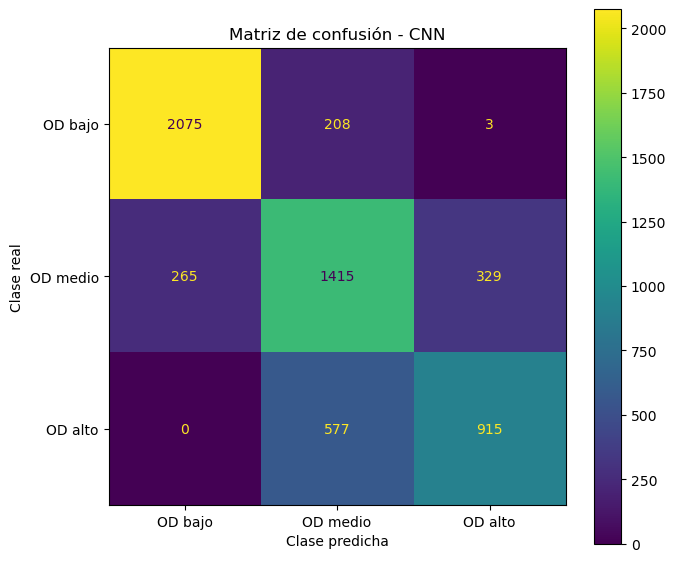

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Crear matriz de confusión
matriz_confusion = confusion_matrix(
    y_val_clases,
    pred_val_clases
)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=nombres_clases
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Matriz de confusión - CNN")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

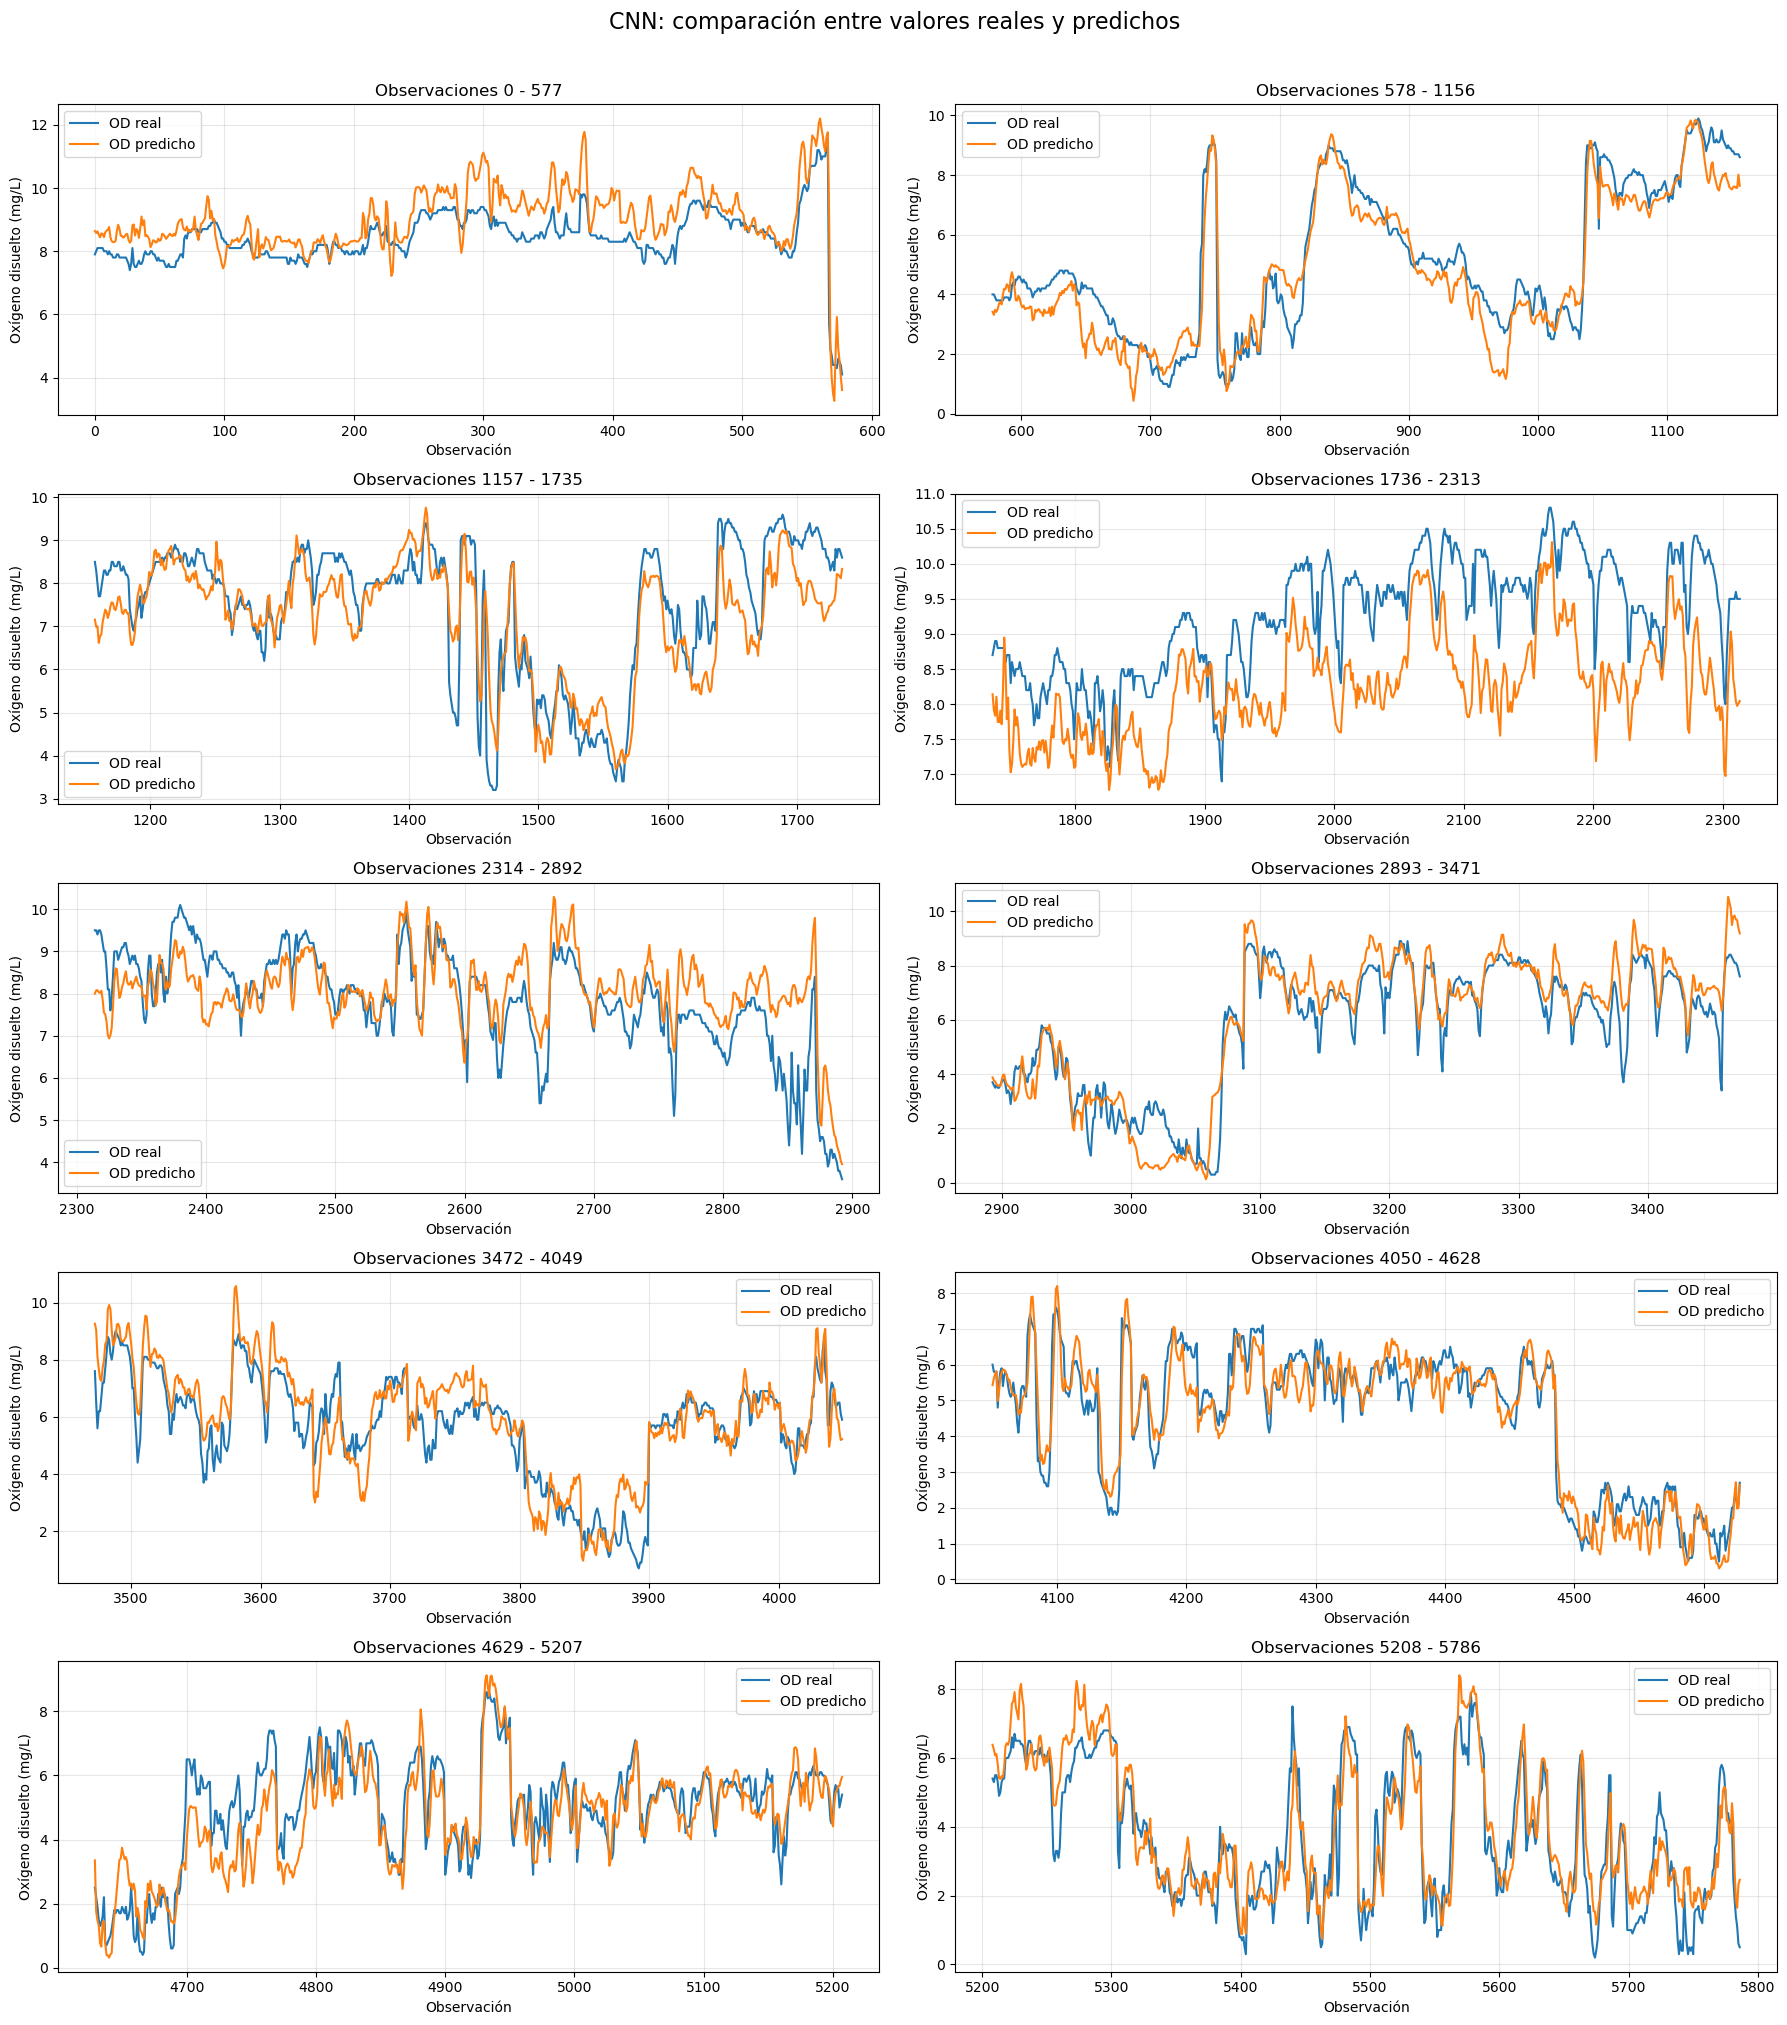

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Cantidad total de observaciones de validación
n = len(y_val)

# Verificar que reales y predicciones tengan la misma longitud
assert len(y_val) == len(pred_val), \
    "y_val y pred_val tienen diferente cantidad de datos"

# Dividir la validación en 10 partes
limites = np.linspace(0, n, 11, dtype=int)

fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    inicio = limites[i]
    fin = limites[i + 1]

    # Valores reales
    ax.plot(
        range(inicio, fin),
        y_val[inicio:fin],
        label="OD real"
    )

    # Predicciones de la CNN
    ax.plot(
        range(inicio, fin),
        pred_val[inicio:fin],
        label="OD predicho"
    )

    ax.set_title(
        f"Observaciones {inicio} - {fin - 1}"
    )
    
    ax.set_xlabel("Observación")
    ax.set_ylabel("Oxígeno disuelto (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    "CNN: comparación entre valores reales y predichos",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()